In [48]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import cmocean as cmo

ds = xr.open_dataset("FlocMod_TEST.nc", decode_times=False)
print(ds)


# Blank out nans 
ds = ds.dropna(dim="N", how="any")

nt = len(ds.time) 
Nens = len(ds.N)
print(Nens)
G = ds.G.values[10,10]
print("Shear stress = ", G)

Ns = len(ds.Ds)

<xarray.Dataset> Size: 302MB
Dimensions:  (time: 10800, Ds: 10, N: 250)
Coordinates:
  * time     (time) float32 43kB 0.0 1.0 2.0 3.0 ... 1.08e+04 1.08e+04 1.08e+04
  * Ds       (Ds) float32 40B 1e-05 1.732e-05 2.999e-05 ... 0.0008085 0.0014
  * N        (N) float32 1kB 1.0 2.0 3.0 4.0 5.0 ... 247.0 248.0 249.0 250.0
Data variables:
    ssc      (time, Ds, N) float64 216MB ...
    G        (time, N) float64 22MB ...
    nf       (time, N) float64 22MB ...
    alpha    (time, N) float64 22MB ...
    beta     (time, N) float64 22MB ...
Attributes:
    title:    floc mod test
250
Shear stress =  30.0


<>:7: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:7: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_391390/1884654837.py:7: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  axs[j].set_title("Ds = %.2f $\mu$m" % (ds.Ds.isel(Ds=Ds).values*1e6))
/tmp/ipykernel_391390/1884654837.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[-5].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0. )


Text(0.5, 0, 'Time [hr]')

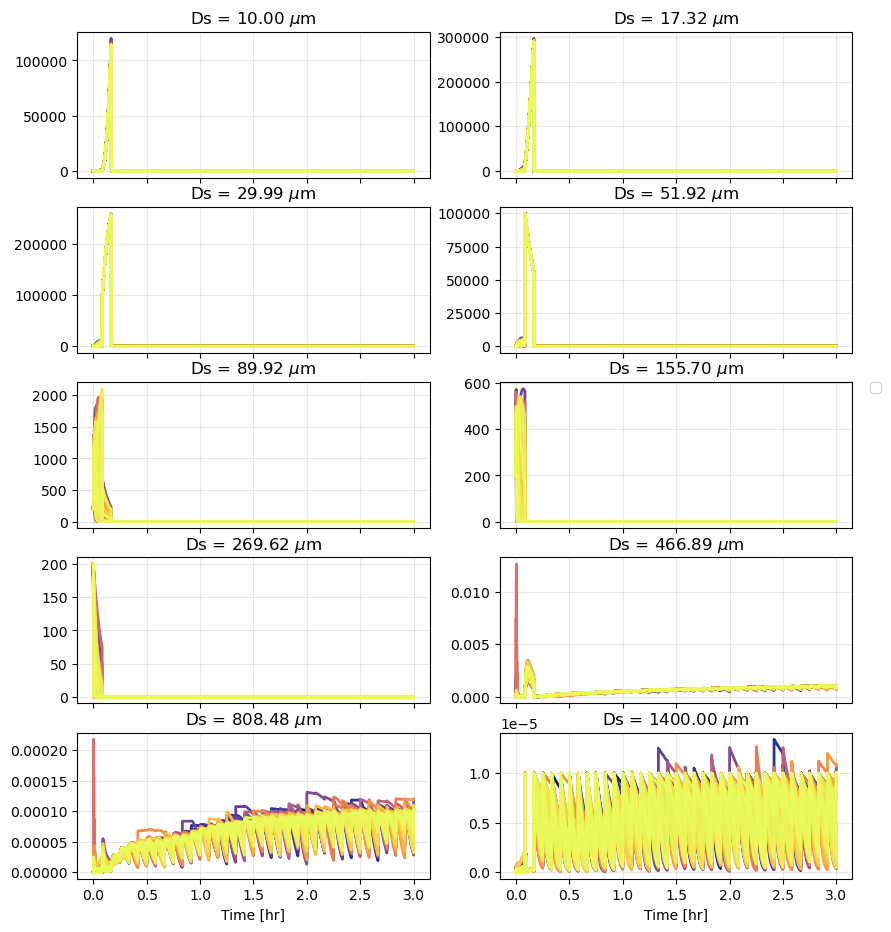

In [49]:
fig, axs = plt.subplots(nrows=5, ncols=2, figsize=(10, 11), sharex=True, sharey=False)
axs = axs.flatten()


for j, Ds in enumerate(range(0, Ns, 1)):
    axs[j].grid(alpha=0.3)
    axs[j].set_title("Ds = %.2f $\mu$m" % (ds.Ds.isel(Ds=Ds).values*1e6))
    time = ds.time.values / 3600
    for i in range(0, Nens):
        G = ds.G.isel(time=1, N=i)
        #ssc       (time, Ds, N)
        # mass = ds.mass.isel(Ds=Ds)
        s0 = ds.ssc.isel(N=i).isel(Ds=Ds)
        axs[j].plot(time, s0, color=cmo.cm.thermal(i/Nens), linewidth=2) #, label="Nens=%d" % i)
        # axs[j].set_ylim(0, 1e4)
axs[-5].legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0. )
axs[-1].set_xlabel("Time [hr]")
axs[-2].set_xlabel("Time [hr]")

# fig.savefig("time_evolution_G=%d.png" % (G), dpi=300, bbox_inches='tight')

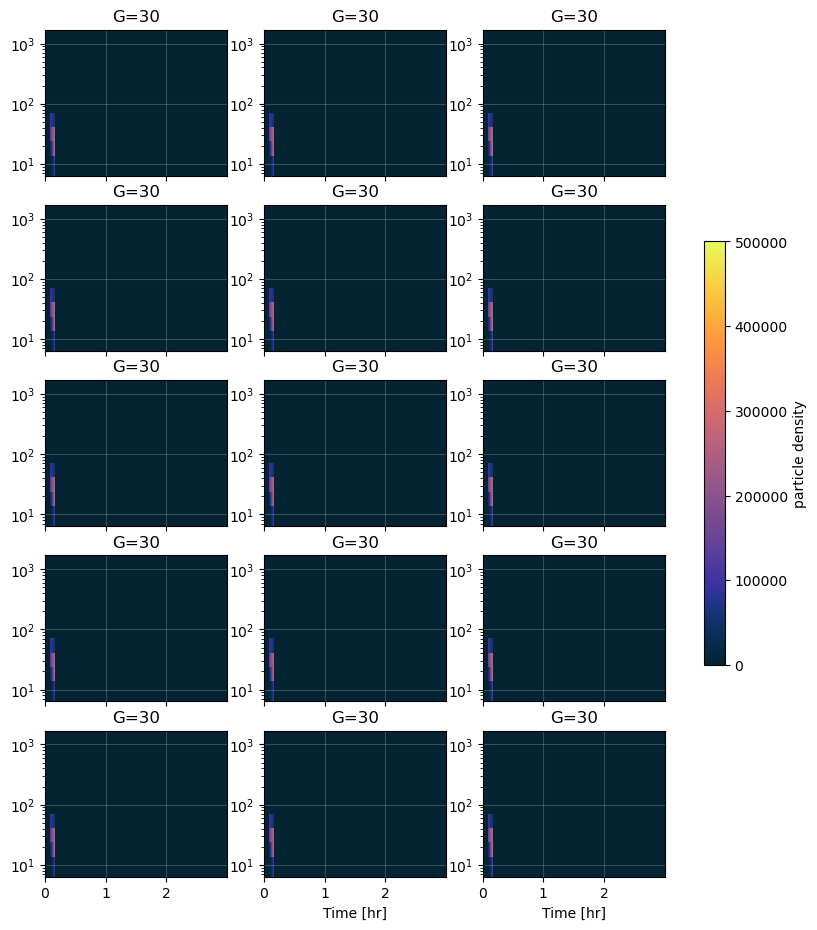

In [50]:
fig, axs = plt.subplots(nrows=5, ncols=3, figsize=(10, 11), sharex=True, sharey=False)
axs = axs.flatten()

for i in range(0, 15):
    G = ds.G.isel(time=1, N=i)
    axs[i].grid(alpha=0.3)
    axs[i].set_title("G=%d" % G)
    time = ds.time.values / 3600
    ssc = ds.ssc.isel(N=i)
    # print(ssc[0:10, 0:5].values)
    h = axs[i].pcolormesh(time, ds.Ds.values*1e6, ssc.T, cmap=cmo.cm.thermal, shading='auto', vmin=0, vmax=0.5e6)
    axs[i].set_yscale("log")
    # axs[i].set_ylabel("D [$\mu$m]")

plt.colorbar(h, ax=axs, orientation='vertical', label="particle density", shrink=0.5)
axs[-1].set_xlabel("Time [hr]")
axs[-2].set_xlabel("Time [hr]")
fig.savefig("time-space_G=%d.png" % (G), dpi=300, bbox_inches='tight')

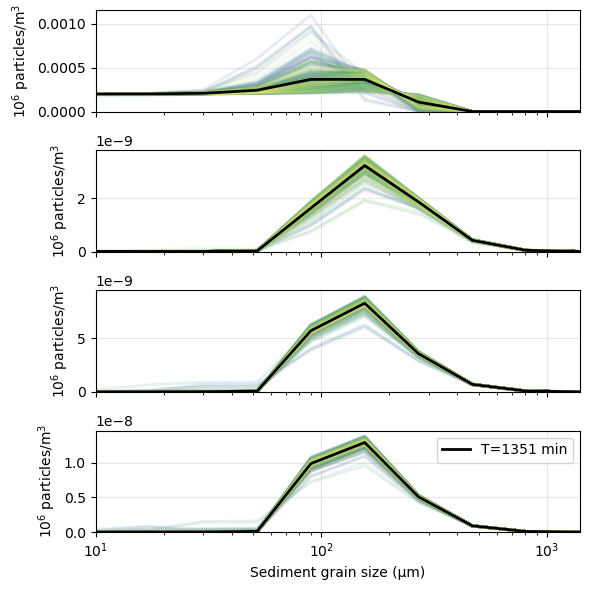

In [51]:
fig, axs = plt.subplots(nrows=4, ncols=1, figsize=(6, 6), sharex=True, sharey=False)


t = 100 

for it, t in enumerate(range(6, nt, nt//4)):
    Ds = ds.Ds.values*1e6
    label="T=%d min" % (t*10/60)
    for i in range(0, Nens):
        var = ds.ssc.isel(time=t, N=i)
        axs[it].plot(Ds, var/1e6, '-', color=cmo.cm.haline(i/Nens), linewidth=2, alpha=0.1) #,color=cmo.cm.thermal(t/nt))
    mean = ds.ssc.isel(time=t).mean(dim="N")
    axs[it].plot(Ds, mean/1e6, '-', color='k', linewidth=2, label=label)

    axs[it].set_xscale('log')
    axs[it].grid(alpha=0.3)
    axs[it].set_ylabel("10$^6$ particles/m$^3$")
    axs[it].set_ylim(0,)
    axs[it].set_xlim(Ds[0], Ds[-1])

axs[-1].set_xlabel("Sediment grain size (µm)")
axs[-1].legend()

plt.tight_layout()

# fig.savefig("pdf_G=%d.png" % (G), dpi=300, bbox_inches='tight')

Text(0.5, 1.0, 'Shear = 30 s$^{-1}$')

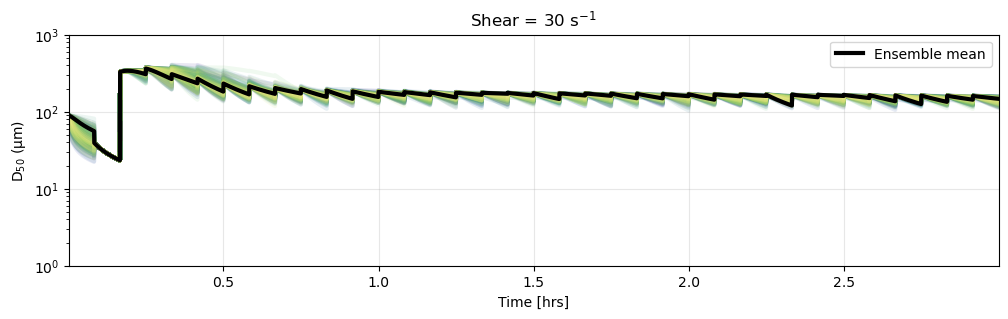

In [52]:
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(12, 3), sharex=True, sharey=True)

var = ds.ssc.mean(dim='N')
weights = var.values + 1e-5
Ds = np.broadcast_to(ds.Ds.values, var.values.shape)
mean_d = np.average(Ds, axis=1, weights=weights)

for n in range(Nens):
    hours = ds.time.values / 3600
    var = ds.ssc.isel(N=n)
    Ds = np.broadcast_to(ds.Ds.values, var.values.shape)
    weights = var.values + 1e-5
    mean_d = np.percentile(Ds, axis=1, q=50, weights=weights, method="inverted_cdf")
    mean_d = np.average(Ds, axis=1, weights=weights)
    ax.plot(hours, mean_d*1e6, color=cmo.cm.haline(n/Nens), alpha=0.1, linewidth=3) #,color=cmo.cm.thermal(t/nt))

ax.plot(hours, mean_d*1e6, color='black', linewidth=3, label="Ensemble mean") 
ax.grid(alpha=0.3)
ax.legend()
ax.set_xlabel("Time [hrs]")
ax.set_ylabel("D$_{50}$ (µm)")
ax.set_xlim(hours[2], hours[-3])
ax.set_ylim(1e-0, 1e3)
ax.set_yscale('log')
ax.set_title("Shear = %d s$^{-1}$" % G)

# fig.savefig("d50_G=%d.png" % (G), dpi=300, bbox_inches='tight')

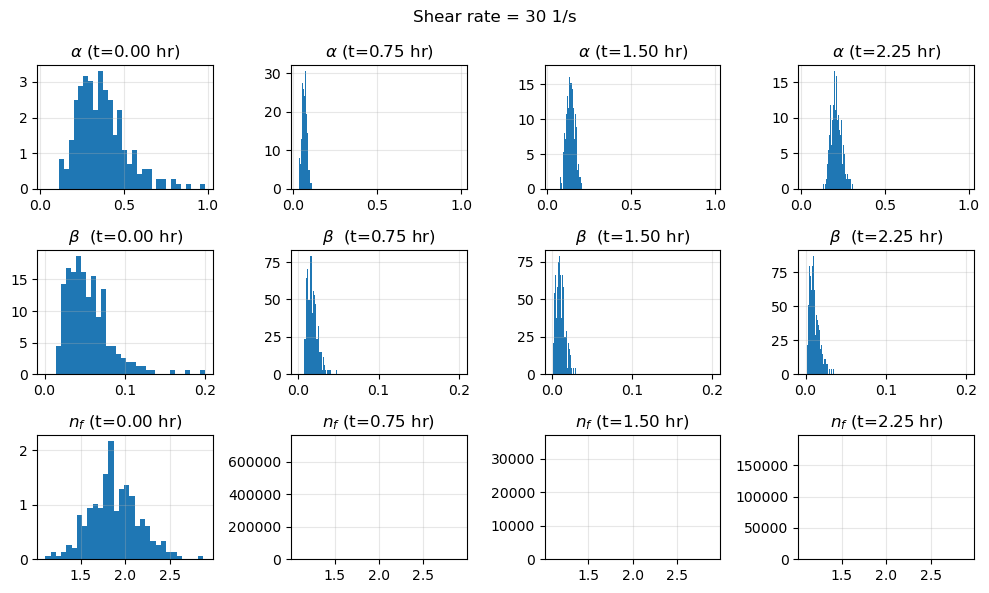

In [55]:
import numpy as np 

fig, axs = plt.subplots(figsize=(10, 6), nrows=3, ncols=4, sharex='row')
plt.suptitle("Shear rate = 30 1/s") #%.2f hr" % (ds.time.isel(time=i).values/3600))

for i, t in enumerate(range(10, nt, nt//4)):

    alphas = ds.alpha.isel(time=t).values
    betas = ds.beta.isel(time=t).values
    nfs = ds.nf.isel(time=t).values

    axs[0, i].hist(alphas, density=True, bins=30) 
    axs[0, i].set_title(r"$\alpha$ (t=%.2f hr)" % (ds.time.isel(time=t).values/3600))
    axs[1, i].hist(betas, density=True, bins=30) 
    axs[1, i].set_title(r"$\beta$  (t=%.2f hr)" % (ds.time.isel(time=t).values/3600))
    axs[2, i].hist(nfs, density=True, bins=30) 
    axs[2, i].set_title("$n_f$ (t=%.2f hr)" % (ds.time.isel(time=t).values/3600))



for ax in axs.flatten():
    ax.grid(alpha=0.3)
plt.tight_layout()
    # axs[0].set_yscale('log')
    # axs[1].set_yscale('log')
    # axs[2].set_yscale('log')

